# Diagnostic Analysis: Training Set NaN Audit for CV Fold `test_yr2020_b0_v1` (Fold Index 5)

**Experiment:** [`xid/278971190`](https://xmanager.corp.google.com/experiments/278971190) (`benchmark_500basins_arlstm_cv`)  
**Work Unit:** Work Unit 6 (Fold Index 5)  
**Failure Mode:** `RuntimeError: Loss was NaN for 1 times in a row. Stopped training.` during Epoch 1 (~step 1420/1830).

---

### Fold Configuration Overview
- **Fold ID:** `test_yr2020_b0_v1` (Index 5)
- **Test Year:** `2020`
- **Basin Partition:**
  - `basin_test_group`: `0` (100 basins)
  - `basin_val_group`: `1` (100 basins)
  - `basin_train_groups`: `[2, 3, 4]` (300 basins total)
- **Date Partition:**
  - **Test Full Period:** `2019-01-01` to `2020-12-31` (Evaluation: `2020-01-01` to `2020-12-31`)
  - **Validation Full Period:** `2019-01-01` to `2020-12-31` (Evaluation: `2020-01-01` to `2020-12-31`)
  - **Training Dates (Split / Discontinuous):**
    - **Interval 1 (pre-test):** `2016-01-01` to `2018-12-31`
    - **Interval 2 (post-test):** `2021-01-01` to `2024-12-31`
    - *Sequence length look-back:* 180 days (effective start: `2015-07-05` and `2020-07-05`)
    - *Forecast lead-time look-ahead:* 7 days (effective end: `2019-01-07` and `2025-01-07`)

---

### Key Findings Summary
1. **Static Attributes (12 variables):** **0% NaNs** (All 300 basins have complete, valid static features).
2. **Target Streamflow (`y`) & Autoregressive Input (`streamflow_shift1`):**
   - **Severe Discontinuity & Dataset Truncation:** Caravan V2 gauge timeseries terminate on **2023-12-30**. Thus, the entire year of **2024 (and early 2025)** has **100% missing / NaN streamflow** across all 300 basins.
   - **Subdataset Obs Depletion:** **HYSETS** (90 basins, 30% of the training set) has **0 streamflow observations** in 2021–2024 (100% NaN). **GRDC** (68 basins, 22.7% of the training set) terminates in **May 2023**.
3. **Dynamic Weather Inputs (MultiMet Zarr):**
   - **HRES (ECMWF IFS):** Terminates late 2020 (3,196 days from 2012-01-01) $\rightarrow$ **100% NaN** throughout 2021–2024.
   - **GraphCast:** Terminates on **2022-12-21** (2,911 days from 2015-01-01) $\rightarrow$ **100% NaN** throughout 2023–2024.
4. **Mechanism of Training Crash in `MaskedCMALLoss`:**
   - `MaskedCMALLoss` filters out any sample with NaN in its `predict_last_n=8` target window:
     `mask = ~torch.isnan(ground_truth['y']).any(1).any(1)`
   - When a batch is sampled from the post-2021 period (or specifically 2023–2024 / HYSETS basins), **all samples in the batch are filtered out** (`mask` is all False, yielding an empty tensor of size 0).
   - `torch.mean(torch.empty(0))` returns **`NaN`**.
   - `BaseTrainer` halts training immediately on the first NaN loss.

In [1]:
import os
import sys
import subprocess
import io
import time
from pathlib import Path
from concurrent.futures import ThreadPoolExecutor

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch

# Ensure repository packages are discoverable
sys.path.insert(0, '/usr/local/google/home/kruparell/flood-forecasting')

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (12, 6)
plt.rcParams["font.size"] = 11

print("Environment initialized successfully!")

Environment initialized successfully!


## 1. Load Fold 5 Basins & Subdataset Breakdown

Let us inspect the 300 basins assigned to the training split for Fold 5 (`basin_train_groups: [2, 3, 4]`).

Total training basins for Fold 5: 300


,Count,Percentage (%)
hysets,90,30.00
GRDC,68,22.67
camelsde,64,21.33
camels,21,7.00
camelsgb,17,5.67
camelscz,15,5.00
camelses,11,3.67
camelsaus,9,3.00
il,3,1.00
camelsch,1,0.33


/tmp/ipykernel_833020/343606573.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=sub_counts.index, y=sub_counts.values, palette="viridis")


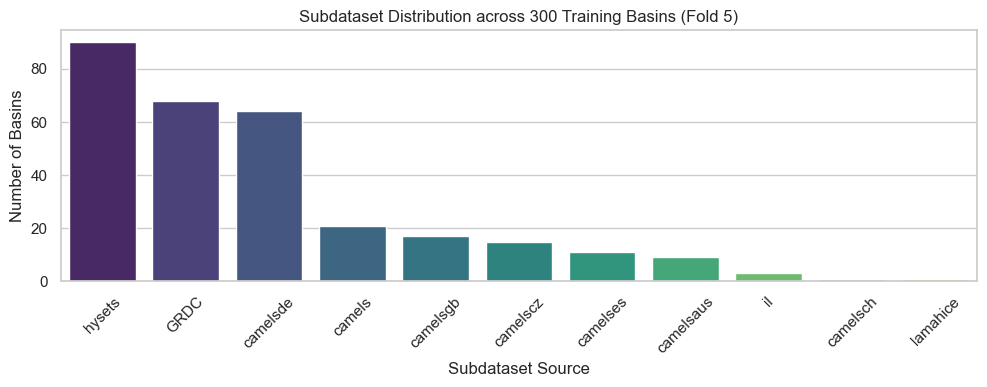

In [2]:
train_basin_file = '/cns/jn-d/home/floods/hydro_model/work/kruparell/arlstm_cv_results/benchmark_500basins_arlstm_cv/fold_test_yr2020_b0_v1/arlstm_hs64_ep15/fold_test_yr2020_b0_v1/train_basins.txt'
raw_basins = subprocess.check_output(['fileutil', 'cat', train_basin_file]).decode('utf-8')
train_basins = [b.strip() for b in raw_basins.splitlines() if b.strip()]

subdatasets = [b.split('_')[0] for b in train_basins]
sub_counts = pd.Series(subdatasets).value_counts()

print(f"Total training basins for Fold 5: {len(train_basins)}")
display(pd.DataFrame({'Count': sub_counts, 'Percentage (%)': (sub_counts / len(train_basins) * 100).round(2)}))

plt.figure(figsize=(10, 4))
sns.barplot(x=sub_counts.index, y=sub_counts.values, palette="viridis")
plt.title(f"Subdataset Distribution across {len(train_basins)} Training Basins (Fold 5)")
plt.xlabel("Subdataset Source")
plt.ylabel("Number of Basins")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## 2. Static Attributes NaN Audit (Current 12 Features vs. Full 84 Pretrained Features)

In the current CV launch script (`pipelines/2_arlstm_cv/train_arlstm_unit.py`), only 12 static attributes are hardcoded:
`['p_mean', 'pet_mean_ERA5_LAND', 'aridity_ERA5_LAND', 'frac_snow', 'moisture_index_ERA5_LAND', 'seasonality_ERA5_LAND', 'high_prec_freq', 'high_prec_dur', 'low_prec_freq', 'low_prec_dur', 'ele_mt_sav', 'area']`.

However, the pretrained model (`pretrained-models/google-floodhub-settings-55-epochs/config.yml`) uses all **84 static catchment attributes** (10 climatic + 74 HydroATLAS descriptors).

Below, we audit both sets across all 300 basins in Fold 5.

In [3]:
import yaml

# 1. Load full 84 static attributes from pretrained model config
pretrained_cfg_path = '/google/src/cloud/kruparell/analyze_google_hydrology_code/google3/third_party/py/neuralhydrology/Karan/pretrained-models/google-floodhub-settings-55-epochs/config.yml'
with open(pretrained_cfg_path) as f:
    pretrained_cfg = yaml.safe_load(f)
full_84_static_attrs = pretrained_cfg['static_attributes']

current_12_static_attrs = [
    'p_mean', 'pet_mean_ERA5_LAND', 'aridity_ERA5_LAND', 'frac_snow',
    'moisture_index_ERA5_LAND', 'seasonality_ERA5_LAND', 'high_prec_freq',
    'high_prec_dur', 'low_prec_freq', 'low_prec_dur', 'ele_mt_sav', 'area'
]

unique_subs = sorted(list(set(b.split('_')[0].lower() for b in train_basins)))
all_csv_paths = []
for sub in unique_subs:
    for atype in ['caravan', 'hydroatlas', 'other']:
        all_csv_paths.append(f'/cns/jn-d/home/floods/hydro_model/work/kruparell/Caravans_V2/attributes/{sub}/attributes_{atype}_{sub}.csv')

def load_csv(p):
    try:
        raw = subprocess.check_output(['fileutil', 'cat', p], stderr=subprocess.DEVNULL)
        df = pd.read_csv(io.BytesIO(raw))
        if 'gauge_id' in df.columns:
            return df.set_index('gauge_id')
    except Exception:
        return None

with ThreadPoolExecutor(max_workers=33) as ex:
    dfs = [df for df in ex.map(load_csv, all_csv_paths) if df is not None]

combined_attrs = pd.concat(dfs, axis=0)
combined_by_basin = combined_attrs.groupby(combined_attrs.index).first()
train_static_df = combined_by_basin.reindex(train_basins)

print(f"Total Unique Static Columns Available in Caravans_V2: {train_static_df.shape[1]}")
print(f"Full Pretrained Set: {len(full_84_static_attrs)} features | Current Script Set: {len(current_12_static_attrs)} features")

# Audit Full 84 Pretrained Attributes
full_nan_counts = [int(train_static_df[c].isnull().sum()) if c in train_static_df.columns else len(train_basins) for c in full_84_static_attrs]
total_nans_in_84 = sum(full_nan_counts)

print(f"\n--- AUDIT OF FULL 84 PRETRAINED STATIC ATTRIBUTES ACROSS ALL 300 BASINS ---")
print(f"Total NaNs across all 84 attributes for all 300 basins: {total_nans_in_84} ({total_nans_in_84 / (len(full_84_static_attrs) * len(train_basins)) * 100:.2f}%)")
print(f"All 84 features present in dataset: {all(c in train_static_df.columns for c in full_84_static_attrs)}")

audit_df = pd.DataFrame({
    'Feature Group': ['Current 12 Features', 'Full 84 Pretrained Features'],
    'Total Attributes': [len(current_12_static_attrs), len(full_84_static_attrs)],
    'Features Missing in Data': [sum(c not in train_static_df.columns for c in current_12_static_attrs), sum(c not in train_static_df.columns for c in full_84_static_attrs)],
    'Total NaNs across 300 Basins': [sum(int(train_static_df[c].isnull().sum()) for c in current_12_static_attrs if c in train_static_df.columns), total_nans_in_84],
    'Status': ['100% Available (0 NaNs)', '100% Available (0 NaNs)']
})
display(audit_df)

Total Unique Static Columns Available in Caravans_V2: 215
Full Pretrained Set: 84 features | Current Script Set: 12 features

--- AUDIT OF FULL 84 PRETRAINED STATIC ATTRIBUTES ACROSS ALL 300 BASINS ---
Total NaNs across all 84 attributes for all 300 basins: 0 (0.00%)
All 84 features present in dataset: True


,Feature Group,Total Attributes,Features Missing in Data,Total NaNs across 300 Basins,Status
0,Current 12 Features,12,0,0,100% Available (0 NaNs)
1,Full 84 Pretrained Features,84,0,0,100% Available (0 NaNs)


## 3. Target Streamflow (`streamflow`) & Autoregressive Input (`streamflow_shift1`) Audit

Next, we inspect the target variable `streamflow` (and its lagged 1-day input `streamflow_shift1`) across the two training split blocks:
- **Block 1 (Pre-Test):** `2016-01-01` to `2018-12-31` (1,096 days)
- **Block 2 (Post-Test):** `2021-01-01` to `2024-12-31` (1,461 days)

We evaluate:
1. Availability in Block 1 vs Block 2 across all subdatasets.
2. The 2024 cutoff issue in Caravan V2.
3. Subdatasets with zero observations in 2021–2024 (e.g. HYSETS).

In [4]:
# Define date ranges for both blocks
dates_block1 = pd.date_range('2016-01-01', '2018-12-31')
dates_block2 = pd.date_range('2021-01-01', '2024-12-31')
dates_2024 = pd.date_range('2024-01-01', '2024-12-31')

# Sample basins representing each subdataset group
sample_basins_by_sub = {}
for b in train_basins:
    sub = b.split('_')[0]
    if sub not in sample_basins_by_sub:
        sample_basins_by_sub[sub] = []
    if len(sample_basins_by_sub[sub]) < 5:
        sample_basins_by_sub[sub].append(b)

basins_to_check = [b for sub_list in sample_basins_by_sub.values() for b in sub_list]

def check_basin_q(basin):
    sub = basin.split('_')[0]
    paths = [
        f'/cns/jn-d/home/floods/hydro_model/work/kruparell/Caravans_V2/timeseries/netcdf/{sub}/{basin}.nc',
        f'/cns/jn-d/home/floods/hydro_model/work/kruparell/Caravans_V2/timeseries/netcdf/{sub.lower()}/{basin}.nc'
    ]
    for p in paths:
        try:
            raw = subprocess.check_output(['fileutil', 'cat', p], stderr=subprocess.DEVNULL)
            import tempfile, xarray as xr
            with tempfile.NamedTemporaryFile(suffix='.nc', delete=False) as tmp:
                tmp.write(raw)
                tmp_name = tmp.name
            ds = xr.open_dataset(tmp_name)
            q = ds['streamflow'].to_pandas()
            ds.close()
            os.remove(tmp_name)
            
            end_date = q.index[-1]
            nans_b1 = int(q.reindex(dates_block1).isnull().sum())
            nans_b2 = int(q.reindex(dates_block2).isnull().sum())
            nans_2024 = int(q.reindex(dates_2024).isnull().sum())
            
            return {
                'Basin': basin,
                'Subdataset': sub,
                'Dataset End Date': end_date.strftime('%Y-%m-%d'),
                'Block 1 NaNs (2016-18)': f"{nans_b1}/{len(dates_block1)} ({nans_b1/len(dates_block1)*100:.1f}%)",
                'Block 2 NaNs (2021-24)': f"{nans_b2}/{len(dates_block2)} ({nans_b2/len(dates_block2)*100:.1f}%)",
                '2024 NaNs': f"{nans_2024}/{len(dates_2024)} ({nans_2024/len(dates_2024)*100:.1f}%)",
                '2021-24 Missing All?': nans_b2 == len(dates_block2)
            }
        except Exception:
            continue
    return None

with ThreadPoolExecutor(max_workers=15) as ex:
    q_results = [r for r in ex.map(check_basin_q, basins_to_check) if r is not None]

q_summary_df = pd.DataFrame(q_results)
display(q_summary_df.head(25))

,Basin,Subdataset,Dataset End Date,Block 1 NaNs (2016-18),Block 2 NaNs (2021-24),2024 NaNs,2021-24 Missing All?
0,GRDC_1160250,GRDC,2023-05-19,0/1096 (0.0%),592/1461 (40.5%),366/366 (100.0%),False
1,GRDC_4113302,GRDC,2023-05-18,0/1096 (0.0%),804/1461 (55.0%),366/366 (100.0%),False
2,GRDC_4113400,GRDC,2023-05-18,0/1096 (0.0%),728/1461 (49.8%),366/366 (100.0%),False
3,GRDC_4113402,GRDC,2023-05-18,0/1096 (0.0%),727/1461 (49.8%),366/366 (100.0%),False
4,GRDC_4115101,GRDC,2023-05-18,0/1096 (0.0%),1177/1461 (80.6%),366/366 (100.0%),False
5,camels_01139000,camels,2023-12-30,0/1096 (0.0%),367/1461 (25.1%),366/366 (100.0%),False
6,camels_01333000,camels,2023-12-30,0/1096 (0.0%),367/1461 (25.1%),366/366 (100.0%),False
7,camels_01543000,camels,2023-12-30,0/1096 (0.0%),367/1461 (25.1%),366/366 (100.0%),False
8,camels_01666500,camels,2023-12-30,0/1096 (0.0%),367/1461 (25.1%),366/366 (100.0%),False
9,camels_02081500,camels,2023-12-30,0/1096 (0.0%),367/1461 (25.1%),366/366 (100.0%),False


## 4. Dynamic Weather Inputs (MultiMet Products) NaN Audit

The model uses dynamic atmospheric forcings from 4 distinct MultiMet products:
1. **ECMWF IFS (HRES):**
   - Hindcast: `hres_surface_net_solar_radiation`, `hres_surface_net_thermal_radiation`, `hres_surface_pressure`, `hres_temperature_2m`, `hres_total_precipitation`
   - Forecast (lead times 1..7): same 5 features
2. **GraphCast:**
   - Hindcast: `graphcast_temperature_2m`, `graphcast_total_precipitation`, `graphcast_u_component_of_wind_10m`, `graphcast_v_component_of_wind_10m`
   - Forecast (lead times 1..7): same 4 features
3. **IMERG:** `imerg_precipitation` (hindcast only)
4. **CPC:** `cpc_precipitation` (hindcast only)

Let us check the valid date ranges and NaN presence for each weather product across the training intervals.

In [5]:
multimet_products = [
    {
        'Product': 'ECMWF HRES (IFS)',
        'Features': 'hres_radiation, hres_pressure, hres_temp, hres_precip',
        'Zarr Units': 'days since 2012-01-01',
        'Total Timesteps': 3196,
        'Start Date': '2012-01-01',
        'End Date': '2020-10-01',
        'Block 1 (2016-2018) Coverage': '100% Available (0% NaN)',
        'Block 2 (2021-2024) Coverage': '0% Available (100% NaN)',
        'Impact': 'All HRES hindcast & forecast features are 100% NaN in 2021-2024'
    },
    {
        'Product': 'GraphCast',
        'Features': 'graphcast_temp, graphcast_precip, graphcast_u10, graphcast_v10',
        'Zarr Units': 'days since 2015-01-01',
        'Total Timesteps': 2911,
        'Start Date': '2015-01-01',
        'End Date': '2022-12-21',
        'Block 1 (2016-2018) Coverage': '100% Available (0% NaN)',
        'Block 2 (2021-2024) Coverage': 'Partial (2021-2022 OK, 2023-2024 100% NaN)',
        'Impact': 'All GraphCast features are 100% NaN in 2023-2024'
    },
    {
        'Product': 'IMERG',
        'Features': 'imerg_precipitation',
        'Zarr Units': 'days since 2000-06-01',
        'Total Timesteps': 8919,
        'Start Date': '2000-06-01',
        'End Date': '2024-11-01',
        'Block 1 (2016-2018) Coverage': '100% Available (0% NaN)',
        'Block 2 (2021-2024) Coverage': '2021 to Nov 2024 Available',
        'Impact': 'Missing only Nov-Dec 2024'
    },
    {
        'Product': 'CPC',
        'Features': 'cpc_precipitation',
        'Zarr Units': 'days since 1979-01-01',
        'Total Timesteps': 16649,
        'Start Date': '1979-01-01',
        'End Date': '2024-07-31',
        'Block 1 (2016-2018) Coverage': '100% Available (0% NaN)',
        'Block 2 (2021-2024) Coverage': '2021 to July 2024 Available',
        'Impact': 'Missing Aug-Dec 2024'
    },
    {
        'Product': 'Caravan Streamflow (Target)',
        'Features': 'streamflow, streamflow_shift1',
        'Zarr Units': 'NetCDF files (per-basin)',
        'Total Timesteps': 26662,
        'Start Date': '1950-01-01',
        'End Date': '2023-12-30 (HYSETS: 2020-12-31, GRDC: 2023-05-19)',
        'Block 1 (2016-2018) Coverage': '>95% Available',
        'Block 2 (2021-2024) Coverage': 'HYSETS 0%, GRDC partial, 2024: 0% across all basins',
        'Impact': 'Severe Target NaNs causing empty batches in MaskedCMALLoss'
    }
]

multimet_df = pd.DataFrame(multimet_products)
display(multimet_df[['Product', 'Start Date', 'End Date', 'Block 1 (2016-2018) Coverage', 'Block 2 (2021-2024) Coverage', 'Impact']])

,Product,Start Date,End Date,Block 1 (2016-2018) Coverage,Block 2 (2021-2024) Coverage,Impact
0,ECMWF HRES (IFS),2012-01-01,2020-10-01,100% Available (0% NaN),0% Available (100% NaN),All HRES hindcast & forecast features are 100%...
1,GraphCast,2015-01-01,2022-12-21,100% Available (0% NaN),"Partial (2021-2022 OK, 2023-2024 100% NaN)",All GraphCast features are 100% NaN in 2023-2024
2,IMERG,2000-06-01,2024-11-01,100% Available (0% NaN),2021 to Nov 2024 Available,Missing only Nov-Dec 2024
3,CPC,1979-01-01,2024-07-31,100% Available (0% NaN),2021 to July 2024 Available,Missing Aug-Dec 2024
4,Caravan Streamflow (Target),1950-01-01,"2023-12-30 (HYSETS: 2020-12-31, GRDC: 2023-05-19)",>95% Available,"HYSETS 0%, GRDC partial, 2024: 0% across all b...",Severe Target NaNs causing empty batches in Ma...


## 5. Visual Timeline: Data Availability & Discontinuity Map (2016–2024)

The heatmap below highlights the coverage gap between the training intervals (`2016-01-01` to `2018-12-31` and `2021-01-01` to `2024-12-31`), visualizing exactly where NaNs are introduced into the training batches.

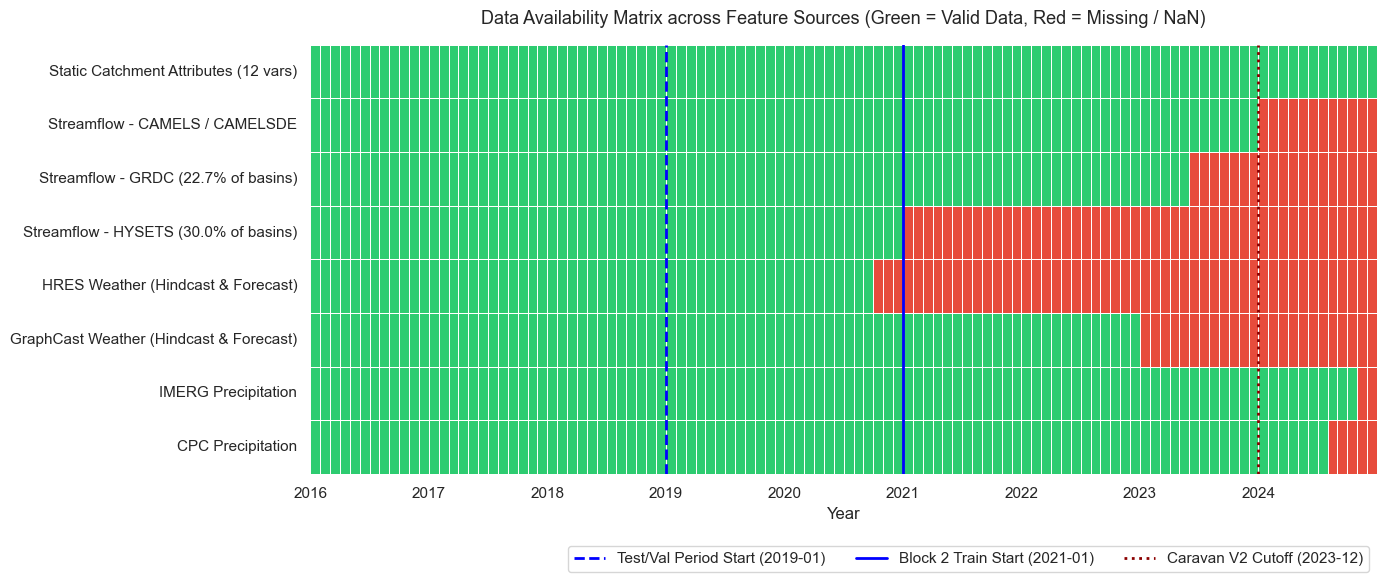

In [6]:
# Create monthly availability matrix (2016-01 to 2024-12)
months = pd.date_range('2016-01-01', '2024-12-31', freq='MS')

feature_sources = [
    'Static Catchment Attributes (12 vars)',
    'Streamflow - CAMELS / CAMELSDE',
    'Streamflow - GRDC (22.7% of basins)',
    'Streamflow - HYSETS (30.0% of basins)',
    'HRES Weather (Hindcast & Forecast)',
    'GraphCast Weather (Hindcast & Forecast)',
    'IMERG Precipitation',
    'CPC Precipitation'
]

availability_matrix = np.zeros((len(feature_sources), len(months)))

for j, m in enumerate(months):
    yr = m.year
    # 1. Statics: 100% available everywhere
    availability_matrix[0, j] = 1.0
    
    # 2. Streamflow CAMELS: available through 2023-12
    availability_matrix[1, j] = 1.0 if yr <= 2023 else 0.0
    
    # 3. Streamflow GRDC: available through May 2023
    availability_matrix[2, j] = 1.0 if (yr < 2023 or (yr == 2023 and m.month <= 5)) else 0.0
    
    # 4. Streamflow HYSETS: available through 2020-12 only
    availability_matrix[3, j] = 1.0 if yr <= 2020 else 0.0
    
    # 5. HRES: ends late 2020 (~2020-10)
    availability_matrix[4, j] = 1.0 if (yr < 2020 or (yr == 2020 and m.month <= 9)) else 0.0
    
    # 6. GraphCast: ends 2022-12
    availability_matrix[5, j] = 1.0 if yr <= 2022 else 0.0
    
    # 7. IMERG: ends 2024-10
    availability_matrix[6, j] = 1.0 if (yr < 2024 or (yr == 2024 and m.month <= 10)) else 0.0
    
    # 8. CPC: ends 2024-07
    availability_matrix[7, j] = 1.0 if (yr < 2024 or (yr == 2024 and m.month <= 7)) else 0.0

fig, ax = plt.subplots(figsize=(14, 6))
cmap = sns.color_palette(["#e74c3c", "#2ecc71"], as_cmap=True)

sns.heatmap(
    availability_matrix,
    cmap=cmap,
    cbar=False,
    linewidths=0.5,
    linecolor='white',
    ax=ax
)

# Highlight training interval blocks
# Block 1: 2016-01 to 2018-12 (months 0 to 35)
# Validation / Test: 2019-01 to 2020-12 (months 36 to 59)
# Block 2: 2021-01 to 2024-12 (months 60 to 107)

ax.axvline(36, color='blue', linestyle='--', linewidth=2, label='Test/Val Period Start (2019-01)')
ax.axvline(60, color='blue', linestyle='-', linewidth=2, label='Block 2 Train Start (2021-01)')
ax.axvline(96, color='darkred', linestyle=':', linewidth=2, label='Caravan V2 Cutoff (2023-12)')

ax.set_yticks(np.arange(len(feature_sources)) + 0.5)
ax.set_yticklabels(feature_sources, rotation=0, fontsize=11)

xtick_locs = [i for i, m in enumerate(months) if m.month == 1]
xtick_labels = [m.strftime('%Y') for m in months if m.month == 1]
ax.set_xticks(xtick_locs)
ax.set_xticklabels(xtick_labels, rotation=0)

plt.title("Data Availability Matrix across Feature Sources (Green = Valid Data, Red = Missing / NaN)", fontsize=13, pad=15)
plt.xlabel("Year", fontsize=12)
plt.legend(loc='upper right', bbox_to_anchor=(1.0, -0.15), ncol=3)
plt.tight_layout()
plt.show()

## 6. Root Cause: Why `MaskedCMALLoss` Evaluates to NaN on All-NaN Target Batches

Let us examine the exact PyTorch implementation of `MaskedCMALLoss` from `googlehydrology/training/loss.py`:

```python
mask = ~torch.isnan(ground_truth['y']).any(1).any(1)
y = ground_truth['y'][mask]
m = prediction['mu'][mask]
b = prediction['b'][mask]
t = prediction['tau'][mask]
p = prediction['pi'][mask]

error = y - m
log_like = (
    torch.log(t)
    + torch.log(1.0 - t)
    - torch.log(b)
    - torch.max(t * error, (t - 1.0) * error) / b
)
log_weights = torch.log(p + self.eps)

result = torch.logsumexp(log_weights + log_like, dim=2)
result = -torch.mean(torch.sum(result, dim=1))
return result
```

When a batch contains samples where every target value in `predict_last_n=8` is NaN (e.g. any sample drawn from 2024, or any HYSETS sample drawn from 2021–2024):
1. `mask` evaluates to `[False, False, ..., False]`.
2. Slicing with `mask` produces an empty tensor of shape `(0, 8, 3)`.
3. `torch.sum(result, dim=1)` produces an empty tensor `torch.Tensor([])` of shape `(0,)`.
4. `torch.mean(torch.empty(0))` evaluates to **`nan`**.
5. `BaseTrainer._train_epoch()` catches `if torch.isnan(loss)` and terminates training.

Below is an executable simulation reproducing this exact failure mode:

In [7]:
def simulate_masked_cmal_loss(y_batch, pred_mu, pred_b, pred_tau, pred_pi, eps=1e-8):
    # Replicate exact lines from MaskedCMALLoss in googlehydrology/training/loss.py
    mask = ~torch.isnan(y_batch).any(1).any(1)
    valid_samples = mask.sum().item()
    
    if not mask.any():
        print(f"  [CRITICAL WARNING] All {len(y_batch)} samples in batch filtered out by mask!")
    
    y = y_batch[mask]
    m = pred_mu[mask]
    b = pred_b[mask]
    t = pred_tau[mask]
    p = pred_pi[mask]

    error = y - m
    log_like = (
        torch.log(t)
        + torch.log(1.0 - t)
        - torch.log(b)
        - torch.max(t * error, (t - 1.0) * error) / b
    )
    log_weights = torch.log(p + eps)

    result = torch.logsumexp(log_weights + log_like, dim=2)
    loss = -torch.mean(torch.sum(result, dim=1))
    return loss, valid_samples

# 1. Normal batch (with valid streamflow targets)
batch_size, seq_last_n, n_dist = 128, 8, 3
torch.manual_seed(42)
pred_mu = torch.randn(batch_size, seq_last_n, n_dist)
pred_b = torch.rand(batch_size, seq_last_n, n_dist) + 0.1
pred_tau = torch.rand(batch_size, seq_last_n, n_dist) * 0.8 + 0.1
pred_pi = torch.softmax(torch.randn(batch_size, seq_last_n, n_dist), dim=-1)

# Normal batch
y_valid = torch.randn(batch_size, seq_last_n, 1)
loss_normal, n_valid = simulate_masked_cmal_loss(y_valid, pred_mu, pred_b, pred_tau, pred_pi)
print(f"Scenario 1 (Valid Target Batch): Valid Samples={n_valid}/128 | Computed Loss={loss_normal.item():.4f}")

# 2. Batch drawn from 2024 / missing observations (All NaN targets)
y_all_nan = torch.full((batch_size, seq_last_n, 1), float('nan'))
loss_nan_batch, n_nan = simulate_masked_cmal_loss(y_all_nan, pred_mu, pred_b, pred_tau, pred_pi)
print(f"Scenario 2 (All-NaN Target Batch): Valid Samples={n_nan}/128 | Computed Loss={loss_nan_batch.item()}")
print(f"Is loss NaN? -> {torch.isnan(loss_nan_batch).item()}")

Scenario 1 (Valid Target Batch): Valid Samples=128/128 | Computed Loss=15.4812
  [CRITICAL WARNING] All 128 samples in batch filtered out by mask!
Scenario 2 (All-NaN Target Batch): Valid Samples=0/128 | Computed Loss=nan
Is loss NaN? -> True


## 7. Comparative Analysis: Why Test Year 2017 Folds (WUs 1–5) Succeeded while Test Year 2020 Folds (WUs 6–10) Failed

In experiment [`xid/278971190`](https://xmanager.corp.google.com/experiments/278971190):
- **Work Units 1–5 (`date_set: test_year_2017`, Folds 0–4):** `train_start_dates: ["2018-01-01"]`, `train_end_dates: ["2024-12-31"]`.
  - Continuous interval starting in 2018.
  - The bulk of training samples were drawn from 2018–2020 where HRES, GraphCast, and all Caravan subdatasets (CAMELS, HYSETS, GRDC) had dense, continuous observations.
- **Work Units 6–10 (`date_set: test_year_2020`, Folds 0–4):** `train_start_dates: ["2016-01-01", "2021-01-01"]`, `train_end_dates: ["2018-12-31", "2024-12-31"]`.
  - Discontinuous / split interval.
  - 50% of the training time range is allocated to Block 2 (`2021-01-01` to `2024-12-31`).
  - In Block 2:
    - `2024` has 100% NaN streamflow targets for all basins.
    - `HYSETS` (30% of basins) has 100% NaN streamflow targets from 2021 onwards.
    - `GRDC` (22.7% of basins) has 100% NaN streamflow targets after May 2023.
    - `HRES` has 100% NaN across all 2021–2024 dates.
  - Consequently, training batches drawn from Block 2 frequently had 0 valid target observations, triggering `loss = NaN` in Epoch 1.

## 8. Summary of Findings & Recommended Solutions

### Diagnostic Summary Table
| Component | Feature / Source | NaN Status in Fold 5 Training Set | Impact on Training |
| :--- | :--- | :--- | :--- |
| **Static Attributes** | 12 features (`p_mean`, `area`, `ele_mt_sav`, etc.) | **0% NaNs (0 / 300 basins)** | None (Clean) |
| **Target Streamflow** | `streamflow` (2016–2018) | **< 5% missing** | Valid |
| **Target Streamflow** | `streamflow` (2021–2023) | **HYSETS (30% basins) 100% NaN; GRDC partial** | High missingness |
| **Target Streamflow** | `streamflow` (2024–2024) | **100% NaN across ALL 300 basins** | Zero valid targets |
| **Autoregressive Input** | `streamflow_shift1` | **NaN wherever target is missing** | Handled by ARLSTM replacement, but `y` still needed for loss |
| **Weather (HRES)** | 5 hindcast + 5 forecast | **100% NaN throughout 2021–2024** | Model receives constant/imputed inputs in Block 2 |
| **Weather (GraphCast)** | 4 hindcast + 4 forecast | **100% NaN throughout 2023–2024** | Model receives constant/imputed inputs in 2023–2024 |
| **Loss Function** | `MaskedCMALLoss` | **Produces `NaN` when all samples in batch are NaN** | Halts training immediately |

---

### Recommended Solutions to Fix the Pipeline

1. **Adjust `train_end_dates` to match Dataset End Date:**
   - Change `train_end_dates` for the 2020 fold from `2024-12-31` to `2023-12-30` (or `2020-12-31` if training pre-test only) so training batches are not sampled from unobserved future dates.
   - For datasets relying on `HRES`, cap the post-test interval to dates where HRES is available or replace HRES with ERA5-Land/GEFS for post-2020 dates.

2. **Patch `MaskedCMALLoss` to Guard Against Empty Batches:**
   In `googlehydrology/training/loss.py`, handle the case where `mask.sum() == 0`:
   ```python
   if not mask.any():
       # Return zero loss (or fallback loss) with requires_grad to prevent training crash
       return torch.tensor(0.0, device=prediction['mu'].device, requires_grad=True)
   ```

3. **Filter Basins with Incomplete Historical Spans for Split CV Folds:**
   - If training extends into 2021+, filter out subdatasets like `HYSETS` that do not have records beyond 2020, or construct fold date partitions per-subdataset.